# 3.1- CLASIFICACIÓN CON KNN
*k-nearest neighbors* O K vecinos cercanos

## 1. Importamos los datos

In [2]:
# Conecto con el Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

## Importo el archivo
asistentes = pd.read_excel('/content/drive/MyDrive/analitica/3. BD1-GymData.xlsx')

## 2. Limpiamos los datos

In [4]:
asistentes.shape

(1000, 4)

In [5]:
## Elimino las filas (registros) donde 'Enroll' está vacío y así filtro a los solicitantes que tienen clasificación
AAA = asistentes.dropna(subset=["Enroll"])

In [6]:
AAA.shape

(1000, 4)

In [7]:
# Inspecciono la variable Enroll
print(AAA.groupby('Enroll').size())

Enroll
0    597
1    403
dtype: int64


In [8]:
## Escojo solo las variables Age, Income y Hours que son las variables independientes del modelo
XD=AAA[['Age', 'Income', 'Hours']]
XD

,Age,Income,Hours
0,26,18000,14
1,43,13000,9
2,55,42000,16
3,55,100000,13
4,55,13000,12
...,...,...,...
995,39,5000,13
996,38,5000,3
997,55,70000,17
998,68,64000,15


In [9]:
## Escojo la variable dependiente del modelo
yd= asistentes['Enroll'].dropna()     ##(un solo corchete para convertirlo facil a array)

In [10]:
yd.shape

(1000,)

## 3. Analizamos la correlación de las variables

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


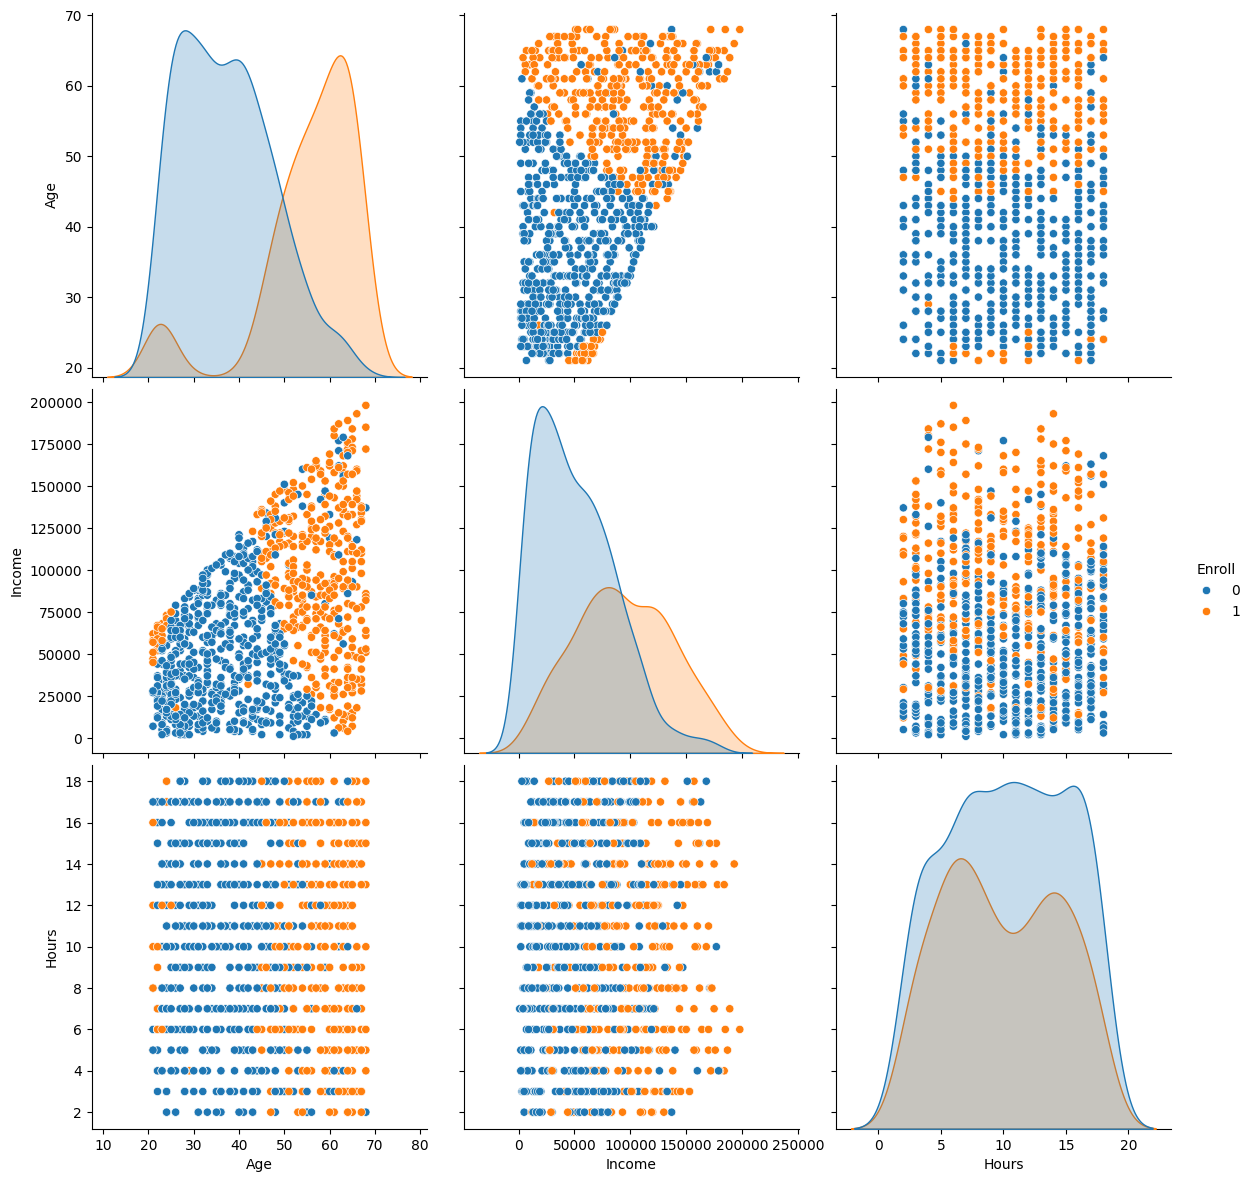

In [11]:
import seaborn as sns

#crear el dashboard
sns.pairplot(AAA, hue='Enroll', size=4, vars=['Age', 'Income', 'Hours'])
#PARA QUE SEAN CORRELACIONADOS TIENE QUE ESTAR EN DIAGONAL FORMANDO UN CONO

Si el cono es mas pulido y mas cerrado hay mayor correlación entre variables

In [12]:
import numpy as np
# Creamos la matriz de correlacion entre las variables
dfinf=pd.DataFrame(np.column_stack((XD,yd)))
dfinf.columns=['Age', 'Income', 'Hours','Enroll']
mCorr=dfinf.corr()
mCorr
#HOURS ES VARIABLE DESCARTABLE PORQUE TIENE POCA CORRELACIÓN, LAS DEMÁS SI TIENEN BUENOS COEFICIENTES

,Age,Income,Hours,Enroll
Age,1.000000,0.450562,-0.040133,0.644033
Income,0.450562,1.000000,-0.018196,0.476372
Hours,-0.040133,-0.018196,1.000000,-0.048184
Enroll,0.644033,0.476372,-0.048184,1.000000


<Axes: >

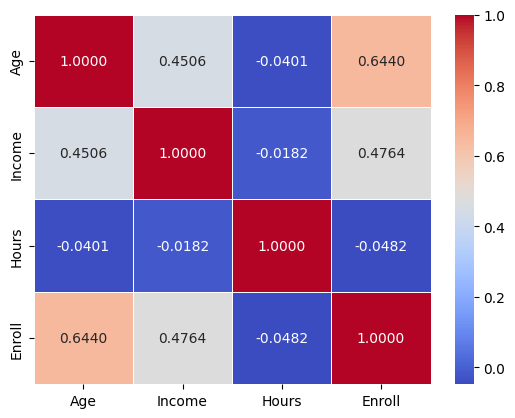

In [13]:
## Volvemos a graficar la matriz de correlación pero ahora como un mapa de calor
sns.heatmap(mCorr, cmap='coolwarm', linewidths=.5, annot=True, fmt=".4f")

In [14]:
# Exportamos la matriz de correlación a excel
mCorr.to_excel('matrizCorrel.xlsx')

## Paso 4 - implementamos modelo KNN


In [15]:
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# Creamos la variable que aloja al modelo
knnModel=KNeighborsClassifier(n_neighbors=10)

In [17]:
# Entreno el modelo (con parametro .fit)
knnModel.fit(XD,yd)

KNeighborsClassifier(n_neighbors=10)

## Matriz de confusion

In [18]:
ydPred = knnModel.predict(XD)

In [19]:
## Creo la matriz de confusion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(yd, ydPred)
cm

array([[538,  59],
       [145, 258]])

## 5. Métricas

In [20]:
## Extraigo los valores de la matriz de confusion
VN=cm[0,0] ; FP=cm[0,1] ; FN=cm[1,0] ; VP=cm[1,1]

In [21]:
## Metricas de evaluacion del modelo
exactitud=(VP+VN)/(VP+VN+FP+FN)
sensibilidad=VP/(VP+FN) #Capacidad del modelo para detectar correctamente los casos positivos.
especificidad=VN/(VN+FP) #Capacidad del modelo para detectar correctamente los casos negativos.
error=1-exactitud
precision=VP/(VP+FP)

In [22]:
## Ejemplo de la impresión de las metricas de evaluacion
print(f'La exactitud del modelo es: {exactitud:.2%}')
print(f'La sensibilidad del modelo es: {sensibilidad:.2%}')
print(f'La especificidad del modelo es: {especificidad:.2%}')
print(f'La tasa de error del modelo es: {error:.2%}')
print(f'La precision del modelo es: {precision:.2%}')

La exactitud del modelo es: 79.60%
La sensibilidad del modelo es: 64.02%
La especificidad del modelo es: 90.12%
La tasa de error del modelo es: 20.40%
La precision del modelo es: 81.39%


In [23]:
XDi = [26, 800, 15]

In [24]:
# Convierto los datos en dataframe y asigno nombres a las columnas
XDi_df = pd.DataFrame([XDi], columns = XD.columns)

In [25]:
ydi = knnModel.predict(XDi_df)
print (f'El resultado del asistente fue {ydi}, es decir {'compró una membresía' if ydi [0]== 1 else 'no compró una membresía'}')

El resultado del asistente fue [0], es decir no compró una membresía


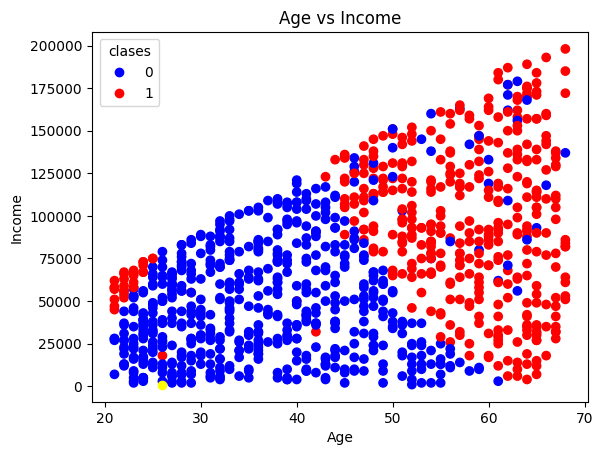

In [26]:
import matplotlib.pyplot as plt
scatter = plt.scatter(XD['Age'],XD ['Income'],
                      c=yd,
                      cmap='bwr')
plt.scatter(XDi_df['Age'], XDi_df ['Income'], facecolor='yellow')
plt.title('Age vs Income')
plt.show
plt.legend(title='clases', *scatter.legend_elements(), bbox_to_anchor=(0.15, 1))
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

## 3.2 Clusterización con K MEANS

#### 3.2.1 Monto el modelo de K-means

In [27]:
from sklearn.cluster import KMeans

# Creamos una semilla de 42 valores
np.random.seed(42)

## Definimos que el modelo va a tener 5 grupos de datos
k=5


In [28]:
## Creamos la variable que aloja el modelo
kMeansModel = KMeans(n_clusters=k, init='random',random_state=42)

In [29]:
## Entrenamos el modelo
kMeansModel.fit(XD, yd)

KMeans(init='random', n_clusters=5, random_state=42)

In [30]:
## Extraemos las etiquetas de los clusteres de los solicitantes
labels = kMeansModel.labels_

### 3.2.2 Graficamos los clusteres y a nuestro solicitante

In [31]:
### Generamos los centroides
centroids = kMeansModel.cluster_centers_
centroids


array([[4.48577236e+01, 8.01463415e+04, 1.03333333e+01],
       [3.97478992e+01, 4.93655462e+04, 1.02815126e+01],
       [5.12611465e+01, 1.15770701e+05, 9.80891720e+00],
       [3.96900369e+01, 1.77601476e+04, 1.01881919e+01],
       [6.00340909e+01, 1.57795455e+05, 1.01363636e+01]])

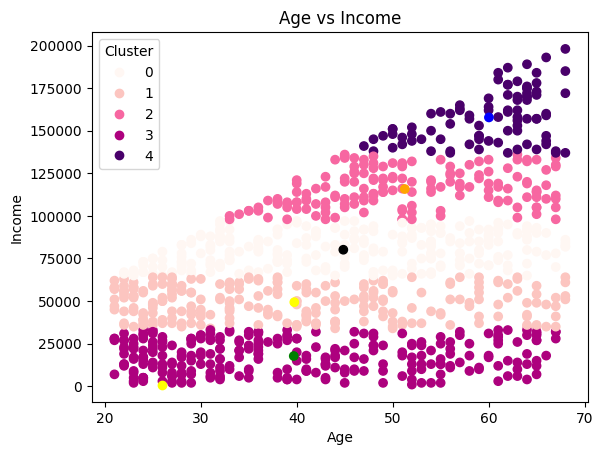

In [32]:
## Graficamos los clusteres
scatter = plt.scatter(XD['Age'],XD ['Income'],
                      c=labels, cmap='RdPu')
plt.scatter(XDi_df['Age'], XDi_df ['Income'], facecolor='yellow')
plt.scatter(centroids[:,0], centroids[:,1],
            facecolor=['black', 'yellow', 'orange', 'green', 'blue'])
plt.title('Age vs Income')
plt.show
plt.legend(title='Cluster', *scatter.legend_elements(), bbox_to_anchor=(0.15, 1))
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [33]:
### Predecimos el cluster de nuestro solicitante (uno mas porque se empieza contar desde 0)
kMeansModel.predict(XDi_df)

array([3], dtype=int32)

## 3.2.3 Generamos informes de los clusteres

In [34]:
## Asigno las etiquetas de cluster a los datos creando una columna "cluster"
AAA.loc[:,'cluster']=labels

## Contamos cuantos Enroll y Not enrolled hay por cada cluster y construimos un df
counts_0=AAA.groupby('cluster').agg({'Enroll':lambda x: (x==0).sum ()})
counts_1=AAA.groupby('cluster').agg({'Enroll':lambda x: (x==1).sum ()})

# Creo un df con esas dos cuenta
df=pd.DataFrame(np.column_stack((counts_0,counts_1)))
df.columns=['Not enrolled','Enroll']
df

## Creamos columna de totales
df['Total']=df.sum (axis=1)
df['probNot enrolled']=df['Not enrolled']/df['Total']
df['probEnroll']=df['Enroll']/df['Total']
df

,Not enrolled,Enroll,Total,probNot enrolled,probEnroll
0,130,116,246,0.528455,0.471545
1,172,66,238,0.722689,0.277311
2,50,107,157,0.318471,0.681529
3,230,41,271,0.848708,0.151292
4,15,73,88,0.170455,0.829545


In [35]:
## Necesito primero completar el df original con una nueva columna donde se indique el cluster para cada solicitante.
AAA.loc[:,'cluster']=labels ## Asigno las etiquetas de cluster a los datos, creando una columna 'cluster'

import plotly.express as px, plotly.graph_objects as go

fig = px.scatter_3d(AAA.astype({'cluster':str}),'Age', 'Income', 'Hours', color='cluster', opacity=1)
# Convierto la figura a una tipo go.Figure para añadirle más puntos
fig = go.Figure(fig)

#Creo el punto para el nuevo solicitante
fig.add_trace(go.Scatter3d(x=[XDi[0]],y=[XDi[1]],z=[XDi[2]], name='Asistente', marker=dict(color='yellow'), mode='markers'))

##Grafico los centroides
fig.add_trace(go.Scatter3d(x=centroids[:,0].tolist(),
                           y=centroids[:,1].tolist(),
                           z=centroids[:,2].tolist(),
                           name='Centroides',
                           marker=dict(color='black'),
                           mode='markers'))
#Ploteo
fig.show()

In [36]:
AAA.groupby(['cluster'])['Income'].max()

,Income
cluster,
0,97000
1,64000
2,136000
3,33000
4,198000


In [37]:
AAA.groupby(['cluster'])['Age'].max()

,Age
cluster,
0,68
1,68
2,67
3,67
4,68


In [38]:
AAA.groupby(['cluster'])['Hours'].max()

,Hours
cluster,
0,18
1,18
2,18
3,18
4,18


In [45]:
# Filtrar solo inscritos (Enroll==1)
inscritos = AAA[AAA["Enroll"] == 1]

# Calcular promedios de Age, Income y Hours por clúster
resumen = inscritos.groupby("cluster")[["Age","Income","Hours"]].mean()

print("Promedios por cluster (solo inscritos):")
print(resumen)

print("\nClúster con mayor promedio de Edad:", resumen["Age"].idxmax())
print("Clúster con mayor promedio de Ingresos:", resumen["Income"].idxmax())
print("Clúster con mayor promedio de Horas:", resumen["Hours"].idxmax())


Promedios por clúster (solo inscritos):
               Age         Income      Hours
cluster                                     
0        53.284483   81034.482759  10.086207
1        50.833333   51393.939394  10.212121
2        55.214953  118242.990654   9.383178
3        60.975610   22731.707317  10.195122
4        60.328767  158219.178082   9.958904

Clúster con mayor promedio de Edad: 3
Clúster con mayor promedio de Ingresos: 4
Clúster con mayor promedio de Horas: 1


1. Describir en el análisis de resultados cada una de las variables que hacen parte de la base de datos.
  Enroll:si el asistente compró o no una membresía
	Age: la edad del asistente
	Income: el ingreso anual del asistente
	Hours: la cantidad promedio de horas que hace ejercicio por semana el asistente

2. Determinar la variable que mejor lleva a cabo el proceso de caracterización de la inscripción de una persona al Gym.
	Age porque es la variable que mayor corelacion tiene con la variable enroll

3. Según las variables de entrada y de salida, determinar cuáles variables tienen una mayor correlación entre ellas.
	Income y age son las variables que mayor correlación tienen

4. Determinar el comportamiento del modelo KNN en el pronóstico de los datos utilizados para la configuración del modelo en cuanto a exactitud, sensibilidad y especificidad.
	Exactitud (79.60%)	El modelo acierta en casi ocho de cada diez predicciones al determinar si un asistente comprará o no la membresía anual. Esto significa que, de manera 		general, es una herramienta confiable para orientar decisiones comerciales; sin embargo, aún existe un 20% de riesgo de error que puede traducirse en 		oportunidades de ventas perdidas o en recursos invertidos en personas que no se inscribirán.
	Sensibilidad (64.02%)	La sensibilidad refleja la capacidad del modelo para identificar a los asistentes que efectivamente compran la membresía. Con un 64%, el modelo está 		dejando escapar aproximadamente a un 36% de compradores reales, lo que representa un costo de oportunidad importante para el gimnasio, ya que 			implica la pérdida de posibles ingresos y la falta de contacto con clientes de alto potencial.
	Especificidad (90.12%)	La especificidad del 90% muestra que el modelo identifica correctamente a la gran mayoría de asistentes que no compran. Este nivel tan alto de acierto 		permite optimizar recursos de marketing y ventas, evitando dedicar tiempo en llamadas de seguimiento o promociones a personas que tienen baja 			probabilidad de inscribirse. Esta métrica es un fuerte del modelo ya qué demuestra buena eficiencia.
	Tasa de error (20.40%)	La tasa de error complementa la exactitud e indica que uno de cada cinco casos es clasificado de manera incorrecta. En la práctica, esto se traduce en 		dos tipos de fallos: gastar esfuerzos en personas que no se inscribirán y, más delicado aún, no darle seguimiento a algunos clientes que sí comprarían. 		Ambos escenarios implican costos, ya sea en tiempo desperdiciado o en ingresos perdidos.
	Precisión (81.39%)	La precisión muestra que, cuando el modelo predice que un asistente comprará la membresía, acierta en más de ocho de cada diez casos. Esto le da un 		valor estratégico a la herramienta, ya que permite enfocar los recursos o promocione únicamente en las personas con mayor probabilidad de conversión, 		aumentando así la eficiencia de las inversiones y el retorno esperado.

5. Determinar si una persona con las siguientes características va a comprar la membresía al Gym utilizando el modelo KNN
["Age","Income","Hours"]= [(26,800,15)]
Este asistente no compró una mebresía

6. De acuerdo con el individuo anterior, llevar a cabo su ubicación en la gráfica del modelo KNN y del modelo KMeans teniendo en cuenta para ello las variables que poseen la mayor correlación entre ellas.

7. Indicar cuál es el clúster que presenta la mayor edad, los mayores ingresos y estarán en el gimnasio por un mayor número de horas, tomando como base solamente los individuos que SÍ harán parte de la membresía.

	El cluster con mayor promedio de Edad es el 4 (indice 3), el cluster con mayor promedio de Ingresos es el (5 indice 4), el cluster con mayor promedio de Horas es el 2 (indice 1)

